# Imports

In [1]:
print('test')

[1] "test"


In [2]:
system.time({
    suppressMessages({
        library(dplyr)
        library(arrow)
        library(patchwork)
        library(ggplot2)
        library(ggpubr)
        library(ggrepel)
        library(purrr)
        library(Seurat)
        library(pheatmap)
        library(RColorBrewer)
        library(edgeR)
        library(stringr)
        library(sf)
        library(qs)
        # library(vegan)
       })
    task_id <- as.integer(Sys.getenv("SLURM_ARRAY_TASK_ID", "1"))
    node <- Sys.getenv("SLURM_JOB_NODELIST","1")
    num_workers = as.integer(Sys.getenv("SLURM_CPUS_PER_TASK","4"))
    print(paste('Task:',task_id,"on",node,'num_workers',num_workers))
    options(future.globals.maxSize =128* 1024^3,
           future.seed=TRUE) 
    # plan("multisession", workers = num_workers)  
    plan("default")
    
    prj = "HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise"
    base = file.path('/ix/rbao/Projects', prj)
    data = file.path(base,'results','jwork')
    scripts= file.path(base,'scripts')
    results = file.path(base,'results','bi_results')
    wdp <- stringr::str_split(getwd(),pattern = '/')[[1]]
    if (wdp[length(wdp)] != 'scripts'){
        print('go up')
        print(getwd())
        setwd('..')
        print(getwd())
    }
    source(file.path(base,'scripts','bi_scripts','cbs_rnaseq_de_library/init.R'))
    # dir.create(results)
    sampleinfo = file.path(base,'sampleinfo')
    pfs.info <- read.csv(file.path(sampleinfo,'PFS_6Month_Status.csv'),row.names = 1)
    pfs.info$patient_id <- pfs.info$Patient.Number
    # info <- read.csv(file.path(results,'seu5.meta.data.csv'),row.names=1)
    info <- read.csv(file.path(results,'seu5.meta.data.with.6M.PFS.csv'), row.names=1)
    dat <- qread(file.path(base,'results/arjun_results/tcell_integration_obj',
                       'combined_tcell_macs_cleaned.qs'))
    subset.info <- dat@meta.data
    test <- read.csv('/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/sampleinfo/309610_rds_matched_info_pfs_03022026_bi.csv',
                 row.names = 1)
    subset.info <- merge(x=subset.info,
                     y=test[,c('barcodes','PFS.6month.status','PFS.6month')],
                     by='barcodes',
                     all.x=TRUE,
                     all.y=FALSE)
    row.names(subset.info) <- subset.info$barcodes
    dat@meta.data <- subset.info[row.names(dat@meta.data),]
    print('complete')
    head(info)
})

[1] "Task: 1 on htc-n44 num_workers 4"
[1] "go up"
[1] "/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/scripts/253-Hillman-LKarapetyan-scRNAseq-revise"
[1] "/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/scripts"
[1] "If using source(./cbs_rnaseq_de_library/init.R) the current wd is set as:"
[1] "/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/scripts"
[1] "Please adjust so './cbs_rnaseq_de_library' will find (i.e. up one folder from current wd)"
[1] "complete"


   user  system elapsed 
 60.000   6.089 584.116 

In [9]:
test <- read.csv('/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/sampleinfo/309610_rds_matched_info_pfs_03022026_bi.csv',
                 row.names = 1)
head(test)

,Patient.Number,orig.ident,nCount_RNA,nFeature_RNA,patient_id,age,sex,stage_enrollment,mutations,collection_site,⋯,RNA_snn_res.0.25,RNA_snn_res.0.1,RNA_snn_res.0.8,barcodes,Man_0.1_celltypes,Man_0.25_celltypes,PFS.6month.status,patientid_timepoint,predicted.id,PFS.6month
,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACCTGAGGGTTTCT-1_1,UOP-002,SeuratProject,2959,1317,UoP002,68,male,IV,NA,groin_lymph_node,⋯,3,2,4,AAACCTGAGGGTTTCT-1_1,Monocytes.+.Macrophages,Myeloid.cells,PFS-free at 6 month,UOP-002_Baseline,cleaned.myeloid,NoPrg6M
AAACCTGCACTACAGT-1_1,UOP-002,SeuratProject,5043,1882,UoP002,68,male,IV,NA,groin_lymph_node,⋯,3,2,8,AAACCTGCACTACAGT-1_1,Monocytes.+.Macrophages,Myeloid.cells,PFS-free at 6 month,UOP-002_Baseline,cleaned.myeloid,NoPrg6M
AAACCTGGTGTGACCC-1_1,UOP-002,SeuratProject,3503,1289,UoP002,68,male,IV,NA,groin_lymph_node,⋯,1,1,3,AAACCTGGTGTGACCC-1_1,Neuroblastoma,Naive.CD4+.T.cells,PFS-free at 6 month,UOP-002_Baseline,CD4+ Tconv,NoPrg6M
AAACCTGTCATACGGT-1_1,UOP-002,SeuratProject,3244,1414,UoP002,68,male,IV,NA,groin_lymph_node,⋯,2,3,2,AAACCTGTCATACGGT-1_1,NK.cells,NK.cells,PFS-free at 6 month,UOP-002_Baseline,NK cells,NoPrg6M
AAACGGGAGGAGCGTT-1_1,UOP-002,SeuratProject,871,443,UoP002,68,male,IV,NA,groin_lymph_node,⋯,2,3,2,AAACGGGAGGAGCGTT-1_1,NK.cells,NK.cells,PFS-free at 6 month,UOP-002_Baseline,NK cells,NoPrg6M
AAACGGGCAGCATACT-1_1,UOP-002,SeuratProject,3263,1307,UoP002,68,male,IV,NA,groin_lymph_node,⋯,3,2,4,AAACGGGCAGCATACT-1_1,Monocytes.+.Macrophages,Myeloid.cells,PFS-free at 6 month,UOP-002_Baseline,cleaned.myeloid,NoPrg6M


In [12]:
# Load cleaned t and myeloid 
system.time({
    dat <- qread(file.path(base,'results/arjun_results/tcell_integration_obj',
                           'combined_tcell_macs_cleaned.qs'))
})

   user  system elapsed 
 37.427   6.236 765.690 

In [14]:
unique(dat$PFS.6month)

[1] "NoPrg6M" "Prg6M"   NA

In [4]:
dim(dat@meta.data)
dim(subset.info)

[1] 252733     38

[1] 252733     38

In [8]:
cell_counts <- subset.info %>% 
  filter(timepoint %in% c('Week4')) %>%
  filter(treatment %in% c('rela','nivo','combo')) %>%
  group_by(treatment,PFS.6month, cell_type_unified) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(cell_type_unified, treatment) %>% 
  filter(all(count > 500)) %>%
  ungroup()
unique(cell_counts$cell_type_unified)
cell_counts

[1] "Activated Transitional"          "CD14+_CD16-_CD33mixed_monocytes"
[3] "CD4+ Tconv"                      "CD4+ Treg"                      
[5] "Naive Memory"                    "Terminally exh/TCR signalling"  
[7] "Tex Intermediate"

treatment,PFS.6month,cell_type_unified,count
<chr>,<chr>,<chr>,<int>
combo,NoPrg6M,Activated Transitional,1175
combo,NoPrg6M,CD14+_CD16-_CD33mixed_monocytes,2729
combo,NoPrg6M,CD4+ Tconv,5982
combo,NoPrg6M,CD4+ Treg,1280
combo,NoPrg6M,Naive Memory,666
combo,NoPrg6M,Terminally exh/TCR signalling,908
combo,Prg6M,Activated Transitional,1075
combo,Prg6M,CD14+_CD16-_CD33mixed_monocytes,1954
combo,Prg6M,CD4+ Tconv,4994


In [26]:
dat <- readRDS(file.path(base,'data','18071_overall_refined_cell_types_ser_obj_230702.rds'))
dat@meta.data <- info[row.names(dat@meta.data),]

In [35]:
file.path(sampleinfo,sprintf('%d_rds_matched_info_pfs.csv',dim(dat@meta.data)[1]))

[1] "/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/sampleinfo/309610_rds_matched_info_pfs.csv"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



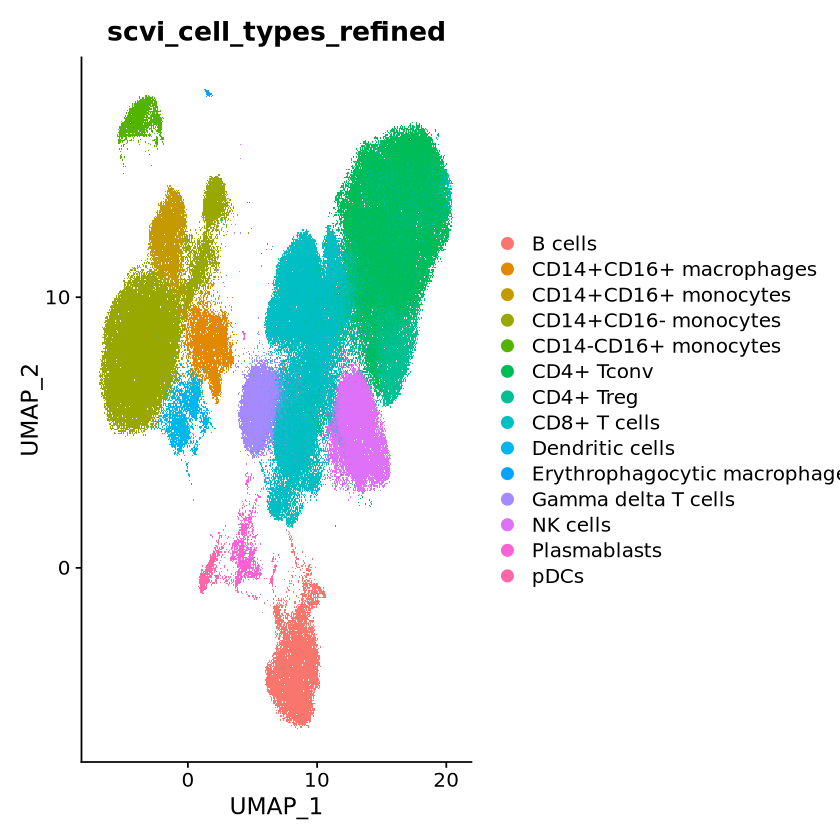

In [21]:
DimPlot(dat, group.by = 'scvi_cell_types_refined')

In [37]:
fn <- file.path(sampleinfo,sprintf('%d_rds_matched_info_pfs_03022026_bi.csv',dim(dat@meta.data)[1]))
print(fn)
write.csv(dat@meta.data, fn)

[1] "/ix/rbao/Projects/HCC-CBS-253-Hillman-LKarapetyan-scRNAseq-revise/sampleinfo/309610_rds_matched_info_pfs_03022026_bi.csv"


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



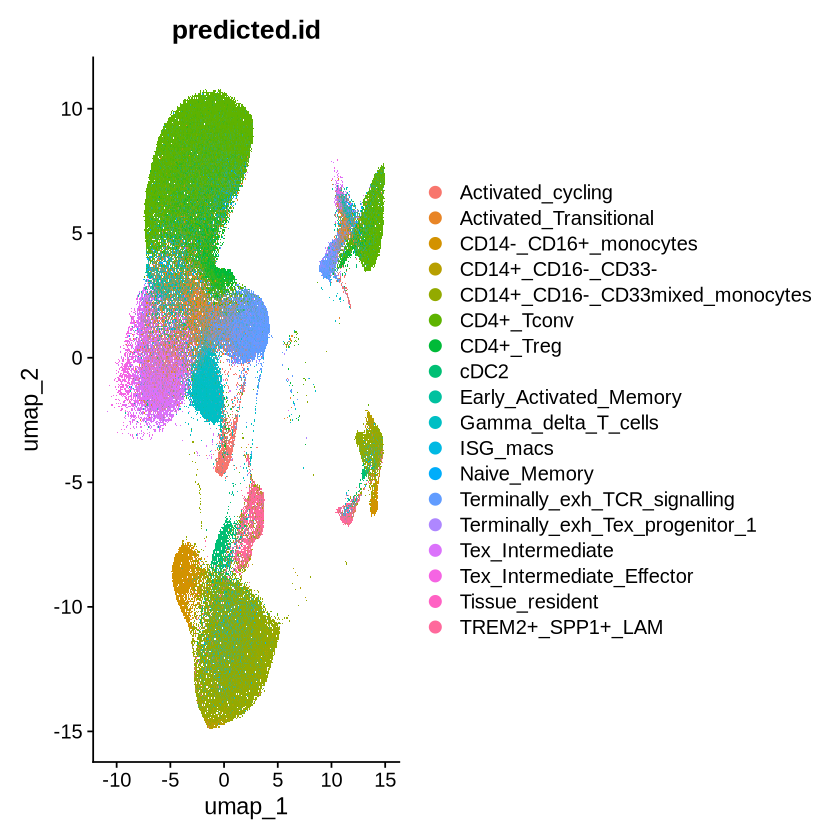

In [19]:
dat@meta.data$predicted.id <- stringr::str_replace_all(dat@meta.data$cell_type_unified, pattern = ' ', replacement = '_')
dat@meta.data$predicted.id <- stringr::str_replace_all(dat$predicted.id, pattern = '/', replacement = '_')
DimPlot(dat, group.by = 'predicted.id')

In [12]:
save.figs <- function(p1,out.dir,base.fn,width,height){
    fn=paste0(base.fn,'.png')
    ggsave(file.path(out.dir,fn),
           plot = p1,
           width = width,
           height = height,
           units = 'in')
    fn=paste0(base.fn,'.pdf')
    ggsave(file.path(out.dir,fn),
           plot = p1,
           width = width,
           height = height,
           units = 'in')
}
volcano.plot <- function(de,p_thresh,log_thresh,title){
    max_abs_x <- max(abs(de$log2FC))
    suppressWarnings({
        p1 <- ggplot(data=de, aes(x=log2FC, y=-log10(p.adj+1e-300), col=diffexpressed, label=delabel)) +
                    geom_point() + 
                    theme_minimal() +
                    geom_text_repel() +
                    scale_color_manual(values=c("blue", "black", "red")) +
                    geom_vline(xintercept=c(-log_thresh, log_thresh), col="red") +
                    geom_hline(yintercept=-log10(p_thresh), col="red") +
                    ggtitle(title) +  xlim(-1.05 * max_abs_x, 1.05 * max_abs_x)
    })

    return(p1)
    }

# heatmap.plot <- function(de,sub,title, ds.pt = 100,
#                          ndeg_top_bottom=15, 
#                          p.thresh=0.05,
#                          plot.tag = c('response_status','any_tobacco_smoker')
#                          ){

#     DefaultAssay(sub) <- "Spatial"
#     Idents(object=sub) <- 'cgf.sample.id'
#     suppressWarnings({sub <- subset(sub, downsample = ds.pt)})
#     DefaultAssay(sub) <- "Spatial"
#     exclude.tma <- df[grepl(pattern = 'TMA',x = df$Original.ID),'CGF.Sample.ID']
#     annotation_col <- sub@meta.data %>% filter(!(cgf.sample.id %in% exclude.tma)) %>%
#       filter(row.names(.) %in% colnames(sub) ) %>%
#       select(all_of(plot.tag)) #cgf.sample.id, 
#     ndeg = ndeg_top_bottom
#     de %>% filter(p_val_adj <  p.thresh) %>% filter(avg_log2FC >0 ) %>%
#                 top_n(n = ndeg, wt =  avg_log2FC) -> top
#     de %>% filter(p_val_adj <  p.thresh) %>% filter(avg_log2FC <0) %>%
#                 top_n(n = ndeg, wt = -avg_log2FC) -> bottom
#     temp <- rbind(top,bottom)
#     use.genes <- unique(temp$Gene)  
#     lognorm.dat <- as.matrix(sub@assays$Spatial$data[use.genes,
#                                                      row.names(annotation_col),
#                                                      drop = FALSE])
#     if (length(use.genes) <= 1){
#         return(NA)
#     }
#     ann_colors <- smoker.ann.colors(plot.tag)
#     # 5. Plot with pheatmap (row scaling built-in)
#      p1 <- pheatmap.wrapper(lognorm.dat, 
#                             annotation_col,
#                             ann_colors,
#                             title)
#     return(p1)
# }
# smoker.ann.colors <- function(plot.tag){
#     smoker_colors <- c("yes" = "red", "no" = "gray80")
#     response_colors <- c("R" = "green3", "NR" = "black")
#     # 4. Define annotation colors
#     if (length(plot.tag) == 2){
#         ann_colors <- list(
#           response_status = response_colors,
#           any_tobacco_smoker = smoker_colors
#         )
#     }else if (plot.tag[1] == 'response_status'){
#         ann_colors <- list( response_status = response_colors)
#     }else if (plot.tag[1] == 'any_tobacco_smoker'){
#         ann_colors <- list(any_tobacco_smoker = smoker_colors)
#     }
#     return(ann_colors)
# }
# pheatmap.wrapper <- function(lognorm.dat, annotation_col, 
#                              ann_colors, title, cluster_rows=TRUE,
#                              cluster_cols=TRUE,
#                              scale="row"){    
  
#    p1<- pheatmap(
#       lognorm.dat,
#       main = title,
#       scale = scale,                 # row-wise z-score normalization
#       annotation_col = annotation_col,
#       annotation_colors = ann_colors,
#       clustering_method = "complete",
#       cluster_rows = cluster_rows,
#       cluster_cols = cluster_cols,
#       color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
#       show_colnames = FALSE,
#       show_rownames = TRUE
#     ) 
#     return(p1)
# }

In [15]:
unique(dat$PFS.6month)

[1] "NoPrg6M" "Prg6M"   NA

In [ ]:
unique(dat@meata.da

In [ ]:
cell.types <- unique(dat@meta.data$predicted.id)

exclude <- c('Terminally_exh_Tex_progenitor_1','Tex_Intermediate_Effector',
             'Gamma_delta_T_cells','Tissue_resident')
cell.types <-  cell.types[!(cell.types %in% exclude)] #too few 'plasmacytoid dendritic cell',
print(cell.types)
use.tags <- c( 'PFS.6month','treatment') # 'treatment', 'timepoint',
test <- 'wilcox'
log.name <- "avg_log2FC"
p.name <- 'p_val_adj'
p = 0.001
log_threshes = c(1, 1.5)
save.filtered <- TRUE
width = 8
height = 6
v=2
suppressWarnings({
    out.gene.lists <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'csv')
    dir.create(out.gene.lists,recursive = TRUE)
    filt.out.gene.lists <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'filtered_csv')
    dir.create(filt.out.gene.lists,recursive = TRUE)
    out.de.volcano <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'volcano')
    dir.create(out.de.volcano,recursive=TRUE)
    out.de.heatmap <- file.path(results,sprintf('DEG_contrasts_%s_v%d',test,v),'heatmap')
    dir.create(out.de.heatmap,recursive=TRUE)
})
plot.volc <- TRUE
plot.heat <- FALSE
min.pct <- 0.03
min.cells.feat = 20
tissue.types <- c( 'PBMC','TIL')
treatments <- c('all.tx')
timepoints <- c('Baseline','Week4') #,'Week16')
system.time({
    for (log_thresh in log_threshes){  
        for (time in timepoints){
            time.sub <- subset(dat, subset = timepoint == time)
            for (tag in use.tags){
                if (tag == 'response_status'){
                    idents <- c('R','NR')
                }else if (tag == 'PFS.6month'){
                    idents <- c('NoPrg6M','Prg6M')
                }else if (tag == 'timepoint'){
                    idents <- c('Week4','Baseline')
                }else if (tag == 'treatment'){
                    idents <- c('combo','rela')
                }else{
                    idents <- c('yes','no')
                }
                comp.sub <- subset(dat, subset = !!sym(tag) %in% idents)
                for (tissue in tissue.types){
                    tissue.sub <- subset(comp.sub, subset = sample_type == tissue)
                    for (treatment in treatments){
                        for (cell in cell.types){
                            if (tag == 'response_status'){
                                 title = sprintf('Respnder vs Non-Responder, %s DEGs',cell)
                            }else if (tag == 'timepoint'){
                                title = sprintf('Week4 vs Baseline, %s DEGs',cell)
                            }else if (tag == 'PFS.6month'){
                                title = sprintf('NoPrg6m vs Prg6M, %s DEGs',cell)
                            } else{
                                 title = sprintf('yes vs no, %s DEGs',cell)
                            }
                            title = paste(tissue, title)
                            if (cell != 'all.cells'){
                                suppressWarnings({sub <- subset(tissue.sub, subset = predicted.id == cell)})
                            } else {
                                sub <- tissue.sub
                            }
                            DefaultAssay(sub) <- "RNA"
                            Idents(sub) <- tag  
                            contrast.str <- paste0(time,'.',treatment,'.',tissue,'.',
                                                   tag,'.',idents[1],'.vs.',idents[2])
                            base.fn <- sprintf('%s.%s.DEG.p%1.3f.log.%1.1f.%s.%d.minpct.v%d',
                                               contrast.str, cell, p,log_thresh, test, min.pct*100,v)
                            base.fn <- stringr::str_replace_all(base.fn,' ','.')
                            fn=paste0(base.fn,'.csv')            
                            if (file.exists(file.path(out.gene.lists,fn))){
                                print(paste('Loading',fn))
                                de <- read.csv(file.path(out.gene.lists,fn),row.names=1)
                            }else{
                                print(paste('Generating',fn))            
                                markers <- FindMarkers(object=sub,
                                                     ident.1 = idents[1],   
                                                     ident.2 = idents[2],      
                                                     base=2,
                                                    min.pct = min.pct,
                                                    min.cells.feature = min.cells.feat, #200 for 10% and 10 for 1%
                                                    min.cells.group = 50,
                                                    test.use = 'wilcox')# 'negbinom', #'wilcox_limma',#'MAST', #
                                                   # latent.vars = c('Patient.Number')) #For models that accept: 'LR', 'negbinom', 'poisson', or 'MAST')
                                de <- markers
                                de$Gene <- row.names(markers)         
                                de$log2FC <- de[[log.name]]   
                                max_fc <- 100
                                de <- de %>%
                                              mutate(
                                                log2FC = case_when(
                                                log2FC == Inf ~ max_fc,
                                                log2FC > max_fc ~ max_fc,
                                                log2FC < -max_fc ~ -max_fc,
                                                log2FC == -Inf ~ -max_fc,
                                                  TRUE ~ log2FC
                                                )
                                              ) %>%
                                              filter(!is.na(p_val_adj)) # Ensure no NAs in p-values
                                de$p.adj <- de[[p.name]]
                                de$diffexpressed <- "NO"    
                                de$diffexpressed[de$log2FC > log_thresh & de$p.adj < p] <- "UP"
                                de$diffexpressed[de$log2FC < -log_thresh & de$p.adj < p] <- "DOWN"
                                de$delabel <- NA
                                de$delabel[de$diffexpressed != "NO"] <- de$Gene[de$diffexpressed != "NO"]                      
                                de <- de %>% arrange(-log2FC,p_val_adj)               
                                de$contrast <- contrast.str 
                                fn=paste0(base.fn,'.csv')
                                write.csv(de,file.path(out.gene.lists,fn))
            
                            }
                            if (save.filtered){
                                filt.de <- de %>% filter(diffexpressed %in% c('UP','DOWN'))
                                fn = paste0('filt.',base.fn,'.csv')
                                write.csv(filt.de, file.path(filt.out.gene.lists,fn))
                            }
                            if (plot.volc){
                                p1 <- volcano.plot(de, p, log_thresh, title)
                                save.figs(p1, out.de.volcano, base.fn, width=width, height=height)
                            }
                            if (plot.heat){
                                if (cell == 'T cell'){
                                    ds.pt = 10
                                    ndeg = 10
                                } else {
                                    ds.pt = 200
                                    ndeg = 15
                                }
                                plot.tag <- tag
                                # make_heatmap_bi(de,sub)
                     #            make_heatmap_bi <- function(de, counts, use_info, output.path, orig.contrast.col=c(), rankby='log2FC',
                     # p = 0.05,  log_thresh = 1, heatmap_top_plus_minus_n = 25,
                     # use.p = 'adj.P.Val', require.p.sig.heatmap = TRUE, version = 1, 
                     # heat.colormap = 'warm', save.figs =TRUE, save.name.tag='',cluster_rows = TRUE, 
                     # cluster_cols = TRUE, save_vector_formats = c('.pdf'),
                     #         added.cols = c(), show_in_line= TRUE){
                                p2 <- heatmap.plot(de, sub, title, plot.tag = plot.tag,
                                                   ndeg_top_bottom = ndeg,  p.thresh=p,
                                                   ds.pt =ds.pt)
                                if (any(!is.na(p2))){
                                    save.figs(p2, out.de.heatmap, base.fn,
                                          width=10, height=5)
                                }else{
                                    print('Too few genes for heatmap')
                                }
                            }
                        }
                    }
                }
            }
        }
    }
})


 [1] "CD14+_CD16-_CD33mixed_monocytes" "ISG_macs"                       
 [3] "CD4+_Tconv"                      "Tex_Intermediate"               
 [5] "Activated_Transitional"          "CD14-_CD16+_monocytes"          
 [7] "cDC2"                            "CD14+_CD16-_CD33-"              
 [9] "Naive_Memory"                    "CD4+_Treg"                      
[11] "TREM2+_SPP1+_LAM"                "Early_Activated_Memory"         
[13] "Activated_cycling"               "Terminally_exh_TCR_signalling"  


Warning message:
“Removing 5452 cells missing data for vars requested”


[1] "Loading Baseline.all.tx.PBMC.PFS.6month.NoPrg6M.vs.Prg6M.CD14+_CD16-_CD33mixed_monocytes.DEG.p0.001.log.1.0.wilcox.3.minpct.v2.csv"


Warning message:
“Removed 4694 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 28 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 4694 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 28 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Loading Baseline.all.tx.PBMC.PFS.6month.NoPrg6M.vs.Prg6M.ISG_macs.DEG.p0.001.log.1.0.wilcox.3.minpct.v2.csv"


...

Warning message:
“Removed 5516 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 94 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 5516 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“ggrepel: 93 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


[1] "Loading Baseline.all.tx.PBMC.PFS.6month.NoPrg6M.vs.Prg6M.Activated_cycling.DEG.p0.001.log.1.0.wilcox.3.minpct.v2.csv"


Warning message:
“Removed 7554 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 7554 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


[1] "Loading Baseline.all.tx.PBMC.PFS.6month.NoPrg6M.vs.Prg6M.Terminally_exh_TCR_signalling.DEG.p0.001.log.1.0.wilcox.3.minpct.v2.csv"


Warning message:
“Removed 4664 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 4664 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
